In [1]:
import numpy as np
from matplotlib import pyplot as plt

# Grab a single npz test file
### This assumes the test file is generated from scripts/icetray/step1/monitoring_extractors/pass3_charge_fadc_gain.py

In [17]:
#x = np.load("/data/ana/Calibration/Pass3_Monitoring/online/icetray/scripts/histograms/Run136692.fadc_atwd_charge.npz")
x = np.load("/data/ana/Calibration/Pass3_Monitoring/online/icetray/scripts/histograms/Run140950.fadc_atwd_charge.npz")
print(x)
bounds = x['bounds']


NpzFile '/data/ana/Calibration/Pass3_Monitoring/online/icetray/scripts/histograms/Run140950.fadc_atwd_charge.npz' with keys: bounds, start, atwd, atwd_mean, atwd_sigma...


Text(0, 0.5, 'ATWD/FADC')

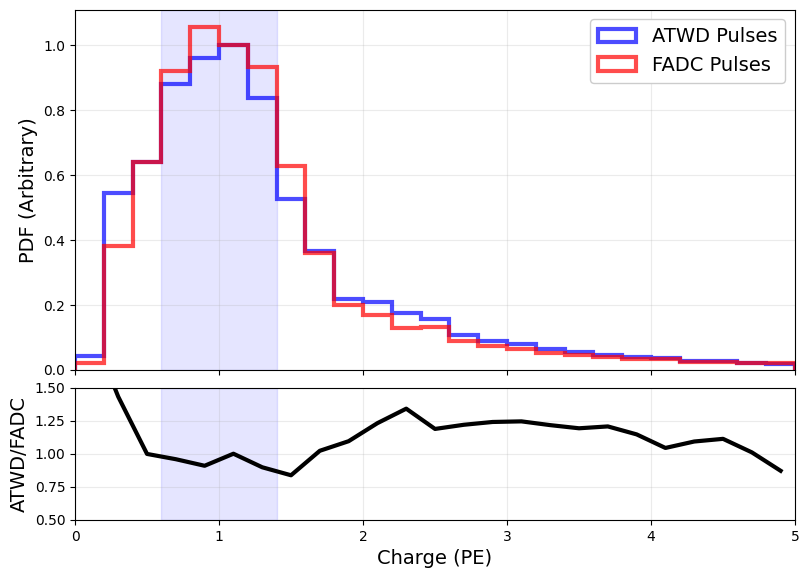

In [18]:
### Plot the ATWD, FADC histograms for a single OMKey
omkey = (21, 42)

fig = plt.figure(figsize=(8,6))
ax0 = fig.add_axes([0.05, 0.35, 0.9, 0.6])
ax1 = fig.add_axes([0.05, 0.10, 0.9, 0.22])

# DST digitizes these with the existing binning, but we still get spikes.
# Merge bins to make this easier to look at.
def merge(hist):
    return hist[0::2] + hist[1::2]
bins = x['bins'][::2]
atwd_hist = merge(x['atwd'][omkey])
fadc_hist = merge(x['fadc'][omkey])

# Find the bin corresponding to Q~1 for normalizations
norm_bin = np.searchsorted(bins, 1)

atwd, bins, _ = ax0.hist(bins[:-1],
                         bins = bins,
                         weights = atwd_hist / atwd_hist[norm_bin],
                         histtype = 'step',
                         linewidth=3,
                         color = 'b',
                         alpha = 0.7,
                         label = 'ATWD Pulses')
fadc, bins, _ = ax0.hist(bins[:-1],
                         bins = bins,
                         weights = fadc_hist / fadc_hist[norm_bin],
                         histtype = 'step',
                         linewidth=3,
                         color = 'r',
                         alpha = 0.7,
                         label = 'FADC Pulses')

# Highlight the fit region
ax0.axvspan(*bounds, 
            color='b',
            alpha=0.1)

ax0.grid(alpha=0.25)
ax0.tick_params(labelsize=10)
ax0.set_xticklabels([])
ax0.set_xlim(x['bins'].min(), x['bins'].max())
ax0.set_ylabel("PDF (Arbitrary)", fontsize=14)
ax0.legend(loc='upper right', framealpha=1, fontsize=14)

# And plot the ratio so we can see how well it corresponds
ax1.plot(bins[:-1]+np.diff(bins)/2,
          atwd/fadc,
         color='k',
        linewidth=3,)
# Highlight the fit region
ax1.axvspan(*bounds, 
            color='b',
            alpha=0.1)
ax1.grid(alpha=0.25)
ax1.tick_params(labelsize=10)
ax1.set_xlim(*ax0.get_xlim())
ax1.set_xlabel("Charge (PE)", fontsize=14)
ax1.set_ylim(0.5, 1.5)
ax1.set_ylabel("ATWD/FADC", fontsize=14)


<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:25: SyntaxWarning: invalid escape sequence '\s'
<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:25: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1256906/989316697.py:24: SyntaxWarning: invalid escape sequence '\m'
  mu = "${\mu}$"
/tmp/ipykernel_1256906/989316697.py:25: SyntaxWarning: invalid escape sequence '\s'
  sigma = "${\sigma}$"


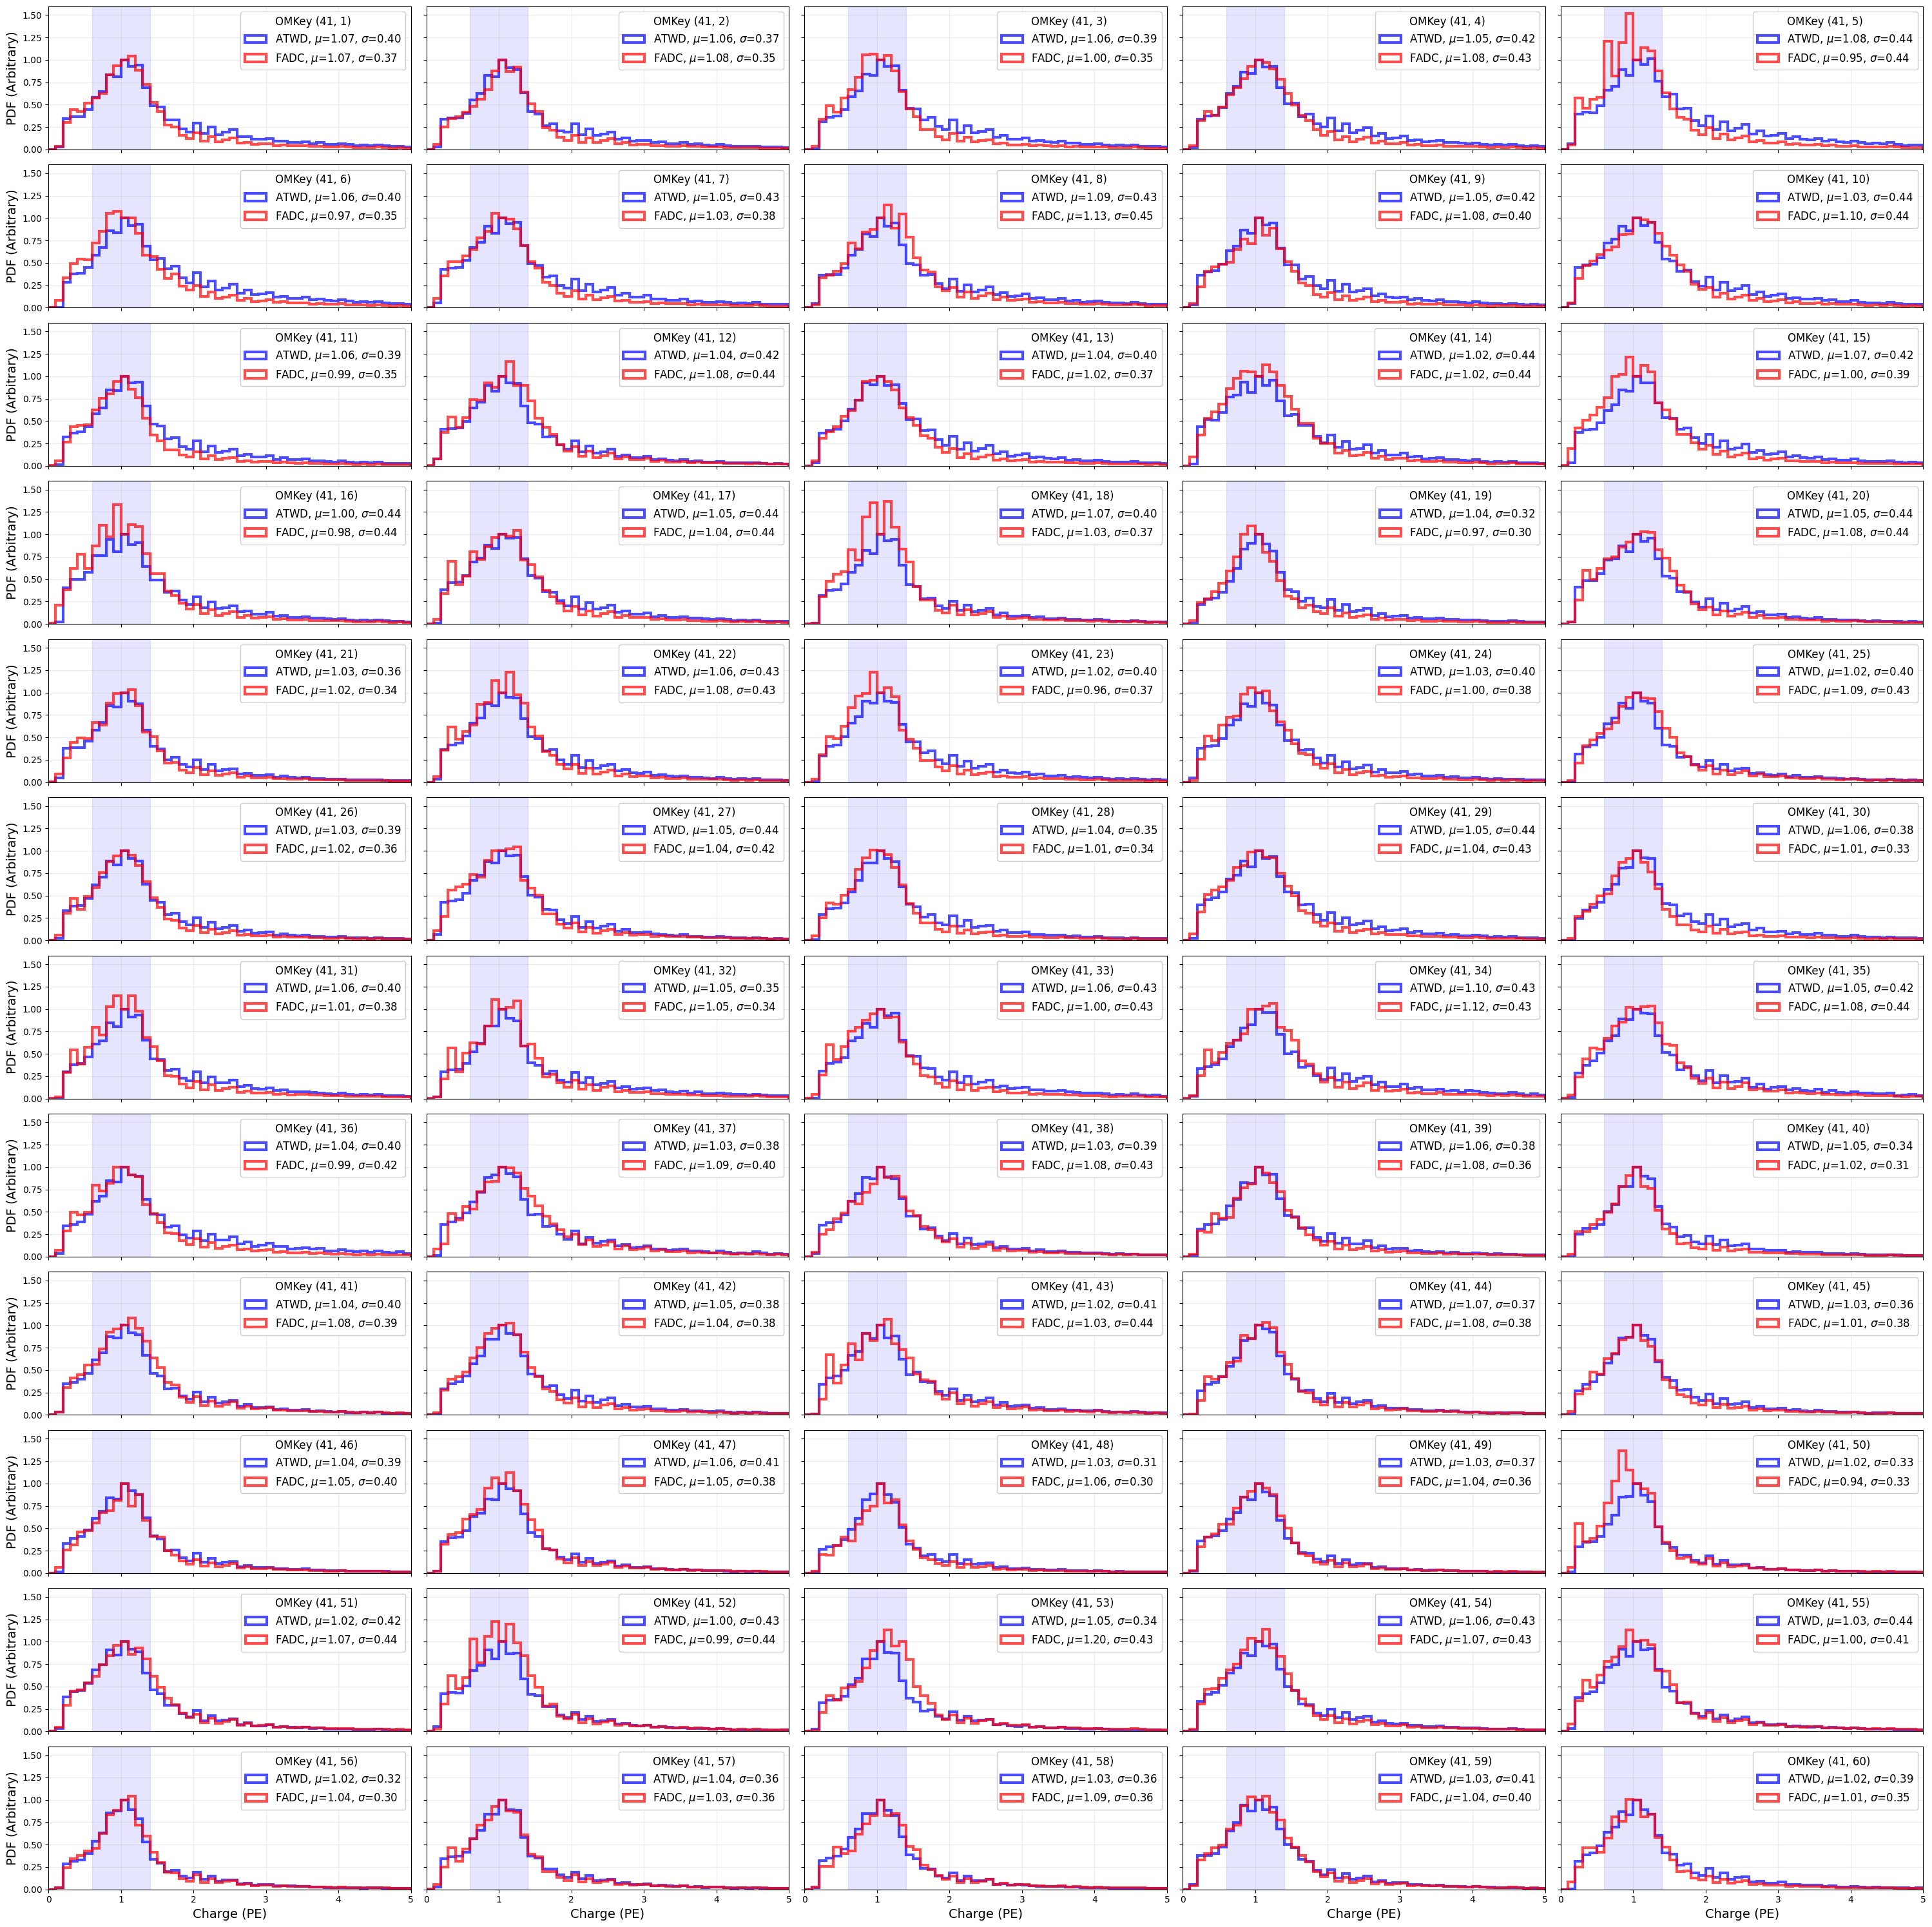

In [19]:
### Plot the ATWD, FADC histograms for a full string
def plot_string(string):
    fig, ax = plt.subplots(12, 5, figsize=(30, 30), sharex=True, sharey=True)
    ax = ax.flatten()
    
    for om in range(1, 61):
        omkey = (string, om)
        ax0 = ax[om-1]
        
        # DST digitizes these with the existing binning, but we still get spikes.
        # Merge bins to make this easier to look at.
        #def merge(hist):
        #    return hist[0::2] + hist[1::2]
        #bins = x['bins'][::2]
        #atwd_hist = merge(x['atwd'][omkey])
        #fadc_hist = merge(x['fadc'][omkey])
        bins = x['bins']
        atwd_hist = (x['atwd'][omkey])
        fadc_hist = (x['fadc'][omkey])
        
        # Find the bin corresponding to Q~1 for normalizations
        norm_bin = np.searchsorted(bins, 1)
    
        mu = "${\mu}$"
        sigma = "${\sigma}$"
    
        ax0.scatter([], [],
                    linewidth=0,
                    s=0,
                    color='w',
                    label = f"OMKey {omkey}")
        
        atwd, bins, _ = ax0.hist(bins[:-1],
                                 bins = bins,
                                 weights = atwd_hist / atwd_hist[norm_bin],
                                 histtype = 'step',
                                 linewidth=3,
                                 color = 'b',
                                 alpha = 0.7,
                                 label = f'ATWD, {mu}={x['atwd_mean'][*omkey]:4.2f}, {sigma}={x['atwd_sigma'][*omkey]:4.2f}')
        fadc, bins, _ = ax0.hist(bins[:-1],
                                 bins = bins,
                                 weights = fadc_hist / fadc_hist[norm_bin],
                                 histtype = 'step',
                                 linewidth=3,
                                 color = 'r',
                                 alpha = 0.7,
                                 label = f'FADC, {mu}={x['fadc_mean'][*omkey]:4.2f}, {sigma}={x['fadc_sigma'][*omkey]:4.2f}')
        
        # Highlight the fit region
        ax0.axvspan(*bounds, 
                    color='b',
                    alpha=0.1)
        
        ax0.grid(alpha=0.25)
        ax0.tick_params(labelsize=10)
        ax0.set_xlim(x['bins'].min(), x['bins'].max())
        ax0.set_xlabel("Charge (PE)", fontsize=14)
        ax0.set_ylabel("PDF (Arbitrary)", fontsize=14)
        ax0.legend(loc='upper right', framealpha=1, fontsize=12)
    
        ax0.label_outer()
    
    fig.tight_layout()

    fig.savefig(f"string_{string}_histograms.pdf")
    return

plot_string(41)

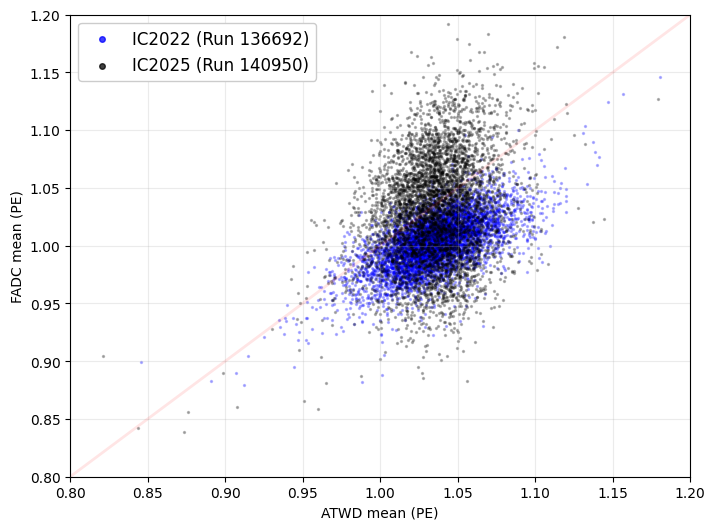

In [25]:
### Plot the FADC and ATwd
omkey = (21, 42)

fig, ax = plt.subplots(figsize=(8,6))

ic2022 = np.load("/data/ana/Calibration/Pass3_Monitoring/online/icetray/scripts/histograms/Run136692.fadc_atwd_charge.npz")
ax.scatter(ic2022['atwd_mean'], ic2022['fadc_mean'],
          s = 2,
          color='b',
           alpha=0.25)
ax.scatter([], [],
          s = 16,
          color='b',
           alpha=0.75, 
          label = "IC2022 (Run 136692)")

ic2025 = np.load("/data/ana/Calibration/Pass3_Monitoring/online/icetray/scripts/histograms/Run140950.fadc_atwd_charge.npz")
ax.scatter(ic2025['atwd_mean'], ic2025['fadc_mean'],
          s = 2,
          color='k',
           alpha=0.25)
ax.scatter([], [],
          s = 16,
          color='k',
           alpha=0.75, 
          label = "IC2025 (Run 140950)")


# plot a 1:1 line
ax.plot([0, 2], [0, 2],
        color='r',
        linewidth=2,
        alpha=0.1)

# There's some cases where we have an FADC, but no ATWD. Those show up on the far left of the plot...
# We also have some extreme outliers at ~(0.4, 0.4). I don't know how useful those are, so I'm just
# going to cut them off for the visualization here. Uncomment these lines if you want to see them.
# There's also points at (0,0). These just come because of a choice I made when generating the ATWD
# and FADC histograms, which both have shape (87, 61). In this case, there is a set of "string 0" and
# "om 0" histograms that are fake. They all show up at (0,0), as do any bad doms not producing data.
ax.set_xlim(0.8, 1.2)
ax.set_ylim(0.8, 1.2)
ax.legend(loc='upper left', framealpha=1, fontsize=12)
ax.set_xlabel("ATWD mean (PE)")
ax.set_ylabel("FADC mean (PE)")
ax.grid(alpha=0.25)